# Training Notebook

## Install Dependicies on HiPerGator

In [1]:
%pip install datasets transformers accelerate seqeval --quiet

Note: you may need to restart the kernel to use updated packages.


## Imports

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
from datasets import load_dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## Config

In [5]:
# All hyperparameters in one place -  makes it easy for us to tune
CONFIG = {
    # General
    'seed'            : 42,
    'max_len'         : 128,
    'num_classes'     : 5,
    'num_workers'     : 4,
    'pin_memory'      : torch.cuda.is_available(),

    # LSTM
    'vocab_size'      : 30000,
    'embed_dim'       : 128,
    'hidden_dim'      : 256,
    'num_layers'      : 2,
    'dropout'         : 0.3,
    'lstm_lr'         : 1e-3,
    'lstm_epochs'     : 50,
    'batch_size_lstm' : 64,
    'lstm_patience'   : 5,

    # DistilBERT
    'bert_lr'         : 2e-5,
    'bert_epochs'     : 20,
    'batch_size_bert' : 128,
    'bert_patience'   : 3,
}

LABEL_NAMES = ['background', 'objective', 'methods', 'results', 'conclusions']
LABEL2IDX   = {l: i for i, l in enumerate(LABEL_NAMES)}
IDX2LABEL   = {i: l for l, i in LABEL2IDX.items()}

# Reproducibility
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Load Data

In [6]:
ds = load_dataset('armanc/pubmed-rct20k')

train_df = ds['train'].to_pandas()
val_df   = ds['validation'].to_pandas()
test_df  = ds['test'].to_pandas()

# Encode labels
train_df['label_idx'] = train_df['label'].map(LABEL2IDX)
val_df['label_idx']   = val_df['label'].map(LABEL2IDX)
test_df['label_idx']  = test_df['label'].map(LABEL2IDX)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('Label encoding:', LABEL2IDX)

Repo card metadata block was not found. Setting CardData to empty.
Generating test split: 100%|██████████| 29578/29578 [00:00<00:00, 980386.78 examples/s]


Train: 176,642 | Val: 29,672 | Test: 29,578
Label encoding: {'background': 0, 'objective': 1, 'methods': 2, 'results': 3, 'conclusions': 4}


## Class Weights (for imbalance)

In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CONFIG['num_classes']),
    y=train_df['label_idx'].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print('Class weights:')
for i, w in enumerate(class_weights):
    print(f'  {IDX2LABEL[i]:<15} {w:.4f}')

Class weights:
  background      1.9198
  objective       2.5530
  methods         0.5959
  results         0.6096
  conclusions     1.3004


## Build Vocab

In [8]:
def build_vocab(texts, max_vocab_size):
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())
    
    # Reserve 0 for padding, 1 for unknown
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab_size - 2):
        vocab[word] = len(vocab)
    
    return vocab

vocab = build_vocab(train_df['text'].tolist(), CONFIG['vocab_size'])
print(f'Vocab size: {len(vocab):,}')
print(f'Sample entries: { {k: vocab[k] for k in list(vocab)[:5]} }')

Vocab size: 30,000
Sample entries: {'<PAD>': 0, '<UNK>': 1, '@': 2, ',': 3, '.': 4}


## LSTM Dataset Class

In [9]:
class LSTMDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.texts  = df['text'].tolist()
        self.labels = df['label_idx'].tolist()
        self.vocab  = vocab
        self.max_len = max_len
        # Pre-encode once to avoid repeated tokenization work every epoch.
        self.encoded_texts = [self.encode(text) for text in self.texts]

    def encode(self, text):
        tokens = text.lower().split()[:self.max_len]
        ids = [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]
        # Pad or truncate to max_len
        ids += [self.vocab['<PAD>']] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.encoded_texts[idx], torch.tensor(self.labels[idx], dtype=torch.long)

train_lstm = LSTMDataset(train_df, vocab, CONFIG['max_len'])
val_lstm   = LSTMDataset(val_df,   vocab, CONFIG['max_len'])
test_lstm  = LSTMDataset(test_df,  vocab, CONFIG['max_len'])

loader_kwargs = {
    'num_workers': CONFIG['num_workers'],
    'pin_memory': CONFIG['pin_memory'],
}
if CONFIG['num_workers'] > 0:
    loader_kwargs['persistent_workers'] = True

train_loader_lstm = DataLoader(train_lstm, batch_size=CONFIG['batch_size_lstm'], shuffle=True, **loader_kwargs)
val_loader_lstm   = DataLoader(val_lstm,   batch_size=CONFIG['batch_size_lstm'], **loader_kwargs)
test_loader_lstm  = DataLoader(test_lstm,  batch_size=CONFIG['batch_size_lstm'], **loader_kwargs)

print(f'Batches — Train: {len(train_loader_lstm)} | Val: {len(val_loader_lstm)} | Test: {len(test_loader_lstm)}')

Batches — Train: 2761 | Val: 464 | Test: 463


## LSTM Model

In [10]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        # Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

lstm_model = LSTMClassifier(
    vocab_size  = len(vocab),
    embed_dim   = CONFIG['embed_dim'],
    hidden_dim  = CONFIG['hidden_dim'],
    num_layers  = CONFIG['num_layers'],
    num_classes = CONFIG['num_classes'],
    dropout     = CONFIG['dropout']
).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'LSTM model ready. Trainable params: {total_params:,}')

LSTM model ready. Trainable params: 6,210,053


## LSTM Training Loop

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

criterion_lstm = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_lstm = Adam(lstm_model.parameters(), lr=CONFIG['lstm_lr'])
scheduler_lstm = ReduceLROnPlateau(optimizer_lstm, patience=2, factor=0.5)

print('Training setup ready.')

Training setup ready.


## Run LSTM Training

In [12]:
lstm_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_epoch_lstm = 0
epochs_no_improve_lstm = 0

for epoch in range(CONFIG['lstm_epochs']):
    train_loss, train_acc = train_epoch(lstm_model, train_loader_lstm, optimizer_lstm, criterion_lstm)
    val_loss, val_acc     = eval_epoch(lstm_model, val_loader_lstm, criterion_lstm)
    scheduler_lstm.step(val_loss)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['train_acc'].append(train_acc)
    lstm_history['val_acc'].append(val_acc)

    # Save best model + early stopping tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch_lstm = epoch + 1
        epochs_no_improve_lstm = 0
        torch.save(lstm_model.state_dict(), 'models/lstm_best.pt')
        tag = '  ← best'
    else:
        epochs_no_improve_lstm += 1
        tag = ''

    print(f'Epoch {epoch+1:02d}/{CONFIG["lstm_epochs"]} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{tag}')

    if epochs_no_improve_lstm >= CONFIG['lstm_patience']:
        print(f'Early stopping triggered at epoch {epoch+1}. Best epoch: {best_epoch_lstm}')
        break

print('\nLSTM training complete.')

Epoch 01/50 | Train Loss: 0.7535 Acc: 0.7493 | Val Loss: 0.5944 Acc: 0.8222  ← best
Epoch 02/50 | Train Loss: 0.5921 Acc: 0.8177 | Val Loss: 0.5692 Acc: 0.8353  ← best
Epoch 03/50 | Train Loss: 0.5376 Acc: 0.8368 | Val Loss: 0.5505 Acc: 0.8418  ← best
Epoch 04/50 | Train Loss: 0.5001 Acc: 0.8494 | Val Loss: 0.5489 Acc: 0.8442  ← best
Epoch 05/50 | Train Loss: 0.4695 Acc: 0.8587 | Val Loss: 0.5373 Acc: 0.8468  ← best
Epoch 06/50 | Train Loss: 0.4437 Acc: 0.8658 | Val Loss: 0.5521 Acc: 0.8459
Epoch 07/50 | Train Loss: 0.4222 Acc: 0.8724 | Val Loss: 0.5676 Acc: 0.8452
Epoch 08/50 | Train Loss: 0.4012 Acc: 0.8781 | Val Loss: 0.5733 Acc: 0.8453
Epoch 09/50 | Train Loss: 0.3626 Acc: 0.8908 | Val Loss: 0.6248 Acc: 0.8480
Epoch 10/50 | Train Loss: 0.3383 Acc: 0.8969 | Val Loss: 0.6248 Acc: 0.8427
Early stopping triggered at epoch 10. Best epoch: 5

LSTM training complete.


## Plot LSTM Training Curves

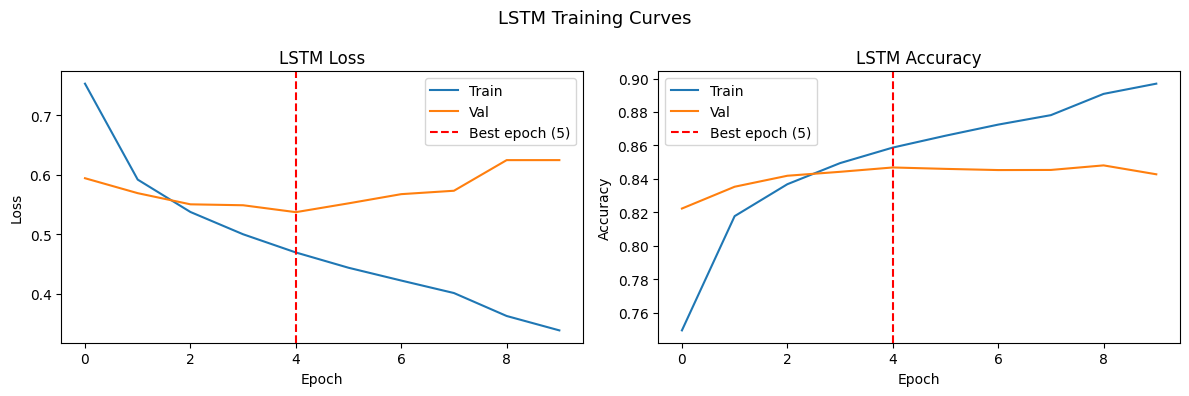

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lstm_history['train_loss'], label='Train')
axes[0].plot(lstm_history['val_loss'],   label='Val')
axes[0].axvline(x=max(best_epoch_lstm - 1, 0), color='red', linestyle='--', label=f'Best epoch ({best_epoch_lstm})')
axes[0].set_title('LSTM Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(lstm_history['train_acc'], label='Train')
axes[1].plot(lstm_history['val_acc'],   label='Val')
axes[1].axvline(x=max(best_epoch_lstm - 1, 0), color='red', linestyle='--', label=f'Best epoch ({best_epoch_lstm})')
axes[1].set_title('LSTM Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('LSTM Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('figures/lstm_curves.png', bbox_inches='tight')
plt.show()

## LSTM Test Evaluation

=== LSTM Test Set Results ===

              precision    recall  f1-score   support

  background       0.61      0.70      0.65      3077
   objective       0.69      0.60      0.64      2333
     methods       0.91      0.93      0.92      9884
     results       0.92      0.88      0.90      9713
 conclusions       0.78      0.80      0.79      4571

    accuracy                           0.84     29578
   macro avg       0.78      0.78      0.78     29578
weighted avg       0.84      0.84      0.84     29578



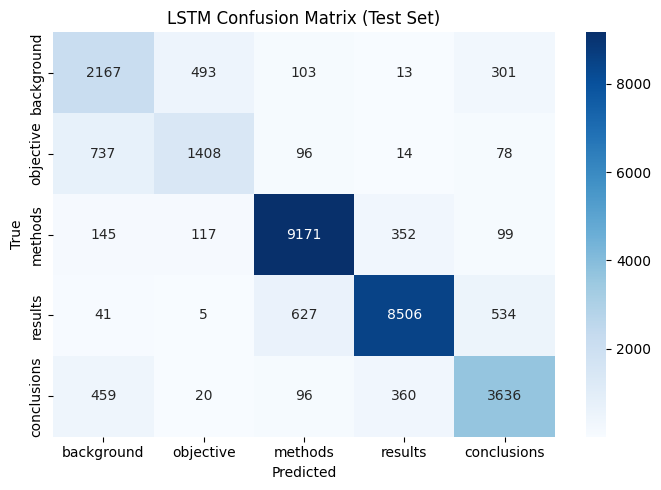

In [14]:
# Load best checkpoint
lstm_model.load_state_dict(torch.load('models/lstm_best.pt'))
lstm_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader_lstm:
        inputs = inputs.to(device)
        outputs = lstm_model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('=== LSTM Test Set Results ===\n')
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('LSTM Confusion Matrix (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('figures/lstm_confusion.png', bbox_inches='tight')
plt.show()

## DistilBERT Dataset

In [15]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class BertDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts   = df['text'].tolist()
        self.labels  = df['label_idx'].tolist()
        self.max_len = max_len
        # Pre-tokenize once to avoid repeated tokenizer calls each epoch.
        self.encodings = tokenizer(
            self.texts,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.encodings['input_ids'][idx],
            'attention_mask' : self.encodings['attention_mask'][idx],
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_bert = BertDataset(train_df, tokenizer, CONFIG['max_len'])
val_bert   = BertDataset(val_df,   tokenizer, CONFIG['max_len'])
test_bert  = BertDataset(test_df,  tokenizer, CONFIG['max_len'])

loader_kwargs_bert = {
    'num_workers': CONFIG['num_workers'],
    'pin_memory': CONFIG['pin_memory'],
}
if CONFIG['num_workers'] > 0:
    loader_kwargs_bert['persistent_workers'] = True

train_loader_bert = DataLoader(train_bert, batch_size=CONFIG['batch_size_bert'], shuffle=True, **loader_kwargs_bert)
val_loader_bert   = DataLoader(val_bert,   batch_size=CONFIG['batch_size_bert'], **loader_kwargs_bert)
test_loader_bert  = DataLoader(test_bert,  batch_size=CONFIG['batch_size_bert'], **loader_kwargs_bert)

print(f'Batches — Train: {len(train_loader_bert)} | Val: {len(val_loader_bert)} | Test: {len(test_loader_bert)}')

Batches — Train: 1381 | Val: 232 | Test: 232


## Load DistilBERT model:

In [16]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=CONFIG['num_classes']
).to(device)

total_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f'DistilBERT ready. Trainable params: {total_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5778.71it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT ready. Trainable params: 66,957,317


## DistilBERT Training Loop

In [17]:
criterion_bert = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_bert = Adam(bert_model.parameters(), lr=CONFIG['bert_lr'])
scheduler_bert = ReduceLROnPlateau(optimizer_bert, patience=1, factor=0.5)

def train_epoch_bert(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch_bert(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_loss += loss.item()
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

print('DistilBERT training setup ready.')

DistilBERT training setup ready.


## Run DistilBERT Training

In [18]:
bert_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss_bert = float('inf')
best_epoch_bert = 0
epochs_no_improve_bert = 0

for epoch in range(CONFIG['bert_epochs']):
    train_loss, train_acc = train_epoch_bert(bert_model, train_loader_bert, optimizer_bert, criterion_bert)
    val_loss, val_acc     = eval_epoch_bert(bert_model, val_loader_bert, criterion_bert)
    scheduler_bert.step(val_loss)

    bert_history['train_loss'].append(train_loss)
    bert_history['val_loss'].append(val_loss)
    bert_history['train_acc'].append(train_acc)
    bert_history['val_acc'].append(val_acc)

    if val_loss < best_val_loss_bert:
        best_val_loss_bert = val_loss
        best_epoch_bert = epoch + 1
        epochs_no_improve_bert = 0
        torch.save(bert_model.state_dict(), 'models/bert_best.pt')
        tag = '  ← best'
    else:
        epochs_no_improve_bert += 1
        tag = ''

    print(f'Epoch {epoch+1:02d}/{CONFIG["bert_epochs"]} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{tag}')

    if epochs_no_improve_bert >= CONFIG['bert_patience']:
        print(f'Early stopping triggered at epoch {epoch+1}. Best epoch: {best_epoch_bert}')
        break

print('\nDistilBERT training complete.')

Epoch 01/20 | Train Loss: 0.5702 Acc: 0.8303 | Val Loss: 0.4769 Acc: 0.8654  ← best
Epoch 02/20 | Train Loss: 0.4624 Acc: 0.8670 | Val Loss: 0.4603 Acc: 0.8650  ← best
Epoch 03/20 | Train Loss: 0.4071 Acc: 0.8839 | Val Loss: 0.4710 Acc: 0.8664
Epoch 04/20 | Train Loss: 0.3492 Acc: 0.9012 | Val Loss: 0.4922 Acc: 0.8631
Epoch 05/20 | Train Loss: 0.2744 Acc: 0.9243 | Val Loss: 0.5624 Acc: 0.8634
Early stopping triggered at epoch 5. Best epoch: 2

DistilBERT training complete.


## Plot DistilBERT Training Curves

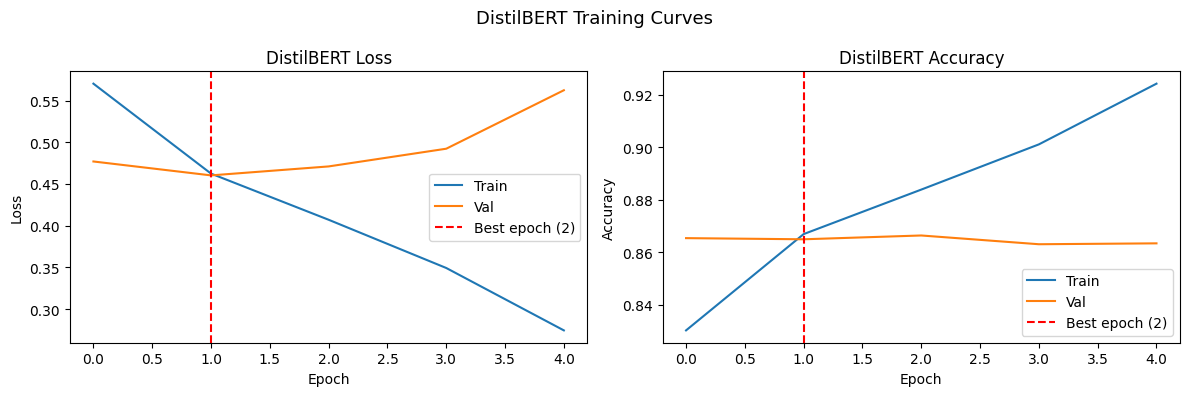

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bert_history['train_loss'], label='Train')
axes[0].plot(bert_history['val_loss'],   label='Val')
axes[0].axvline(x=max(best_epoch_bert - 1, 0), color='red', linestyle='--', label=f'Best epoch ({best_epoch_bert})')
axes[0].set_title('DistilBERT Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(bert_history['train_acc'], label='Train')
axes[1].plot(bert_history['val_acc'],   label='Val')
axes[1].axvline(x=max(best_epoch_bert - 1, 0), color='red', linestyle='--', label=f'Best epoch ({best_epoch_bert})')
axes[1].set_title('DistilBERT Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('DistilBERT Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('figures/distilbert_curves.png', bbox_inches='tight')
plt.show()

## DistilBERT Test Evaluation

=== DistilBERT Test Set Results ===

              precision    recall  f1-score   support

  background       0.65      0.73      0.69      3077
   objective       0.68      0.64      0.66      2333
     methods       0.93      0.93      0.93      9884
     results       0.93      0.88      0.91      9713
 conclusions       0.79      0.85      0.82      4571

    accuracy                           0.86     29578
   macro avg       0.80      0.81      0.80     29578
weighted avg       0.86      0.86      0.86     29578



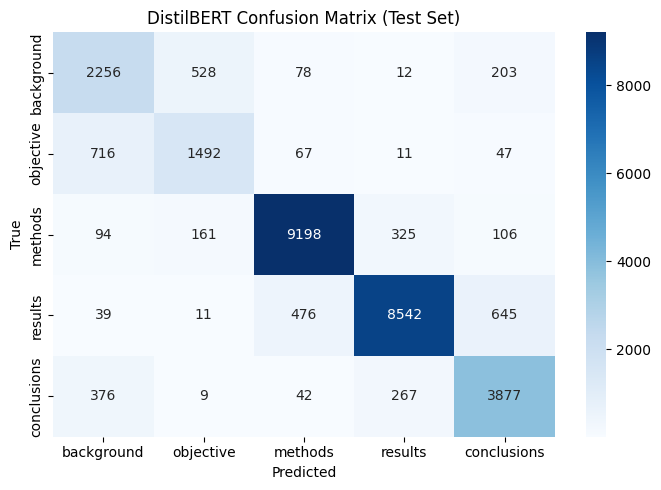

In [20]:
bert_model.load_state_dict(torch.load('models/bert_best.pt'))
bert_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader_bert:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels']

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('=== DistilBERT Test Set Results ===\n')
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('DistilBERT Confusion Matrix (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('figures/distilbert_confusion.png', bbox_inches='tight')
plt.show()

## Model Comparison

=== Model Comparison ===

       Class  LSTM F1  DistilBERT F1
  background     0.63           0.69
   objective     0.64           0.63
     methods     0.91           0.93
     results     0.89           0.90
 conclusions     0.78           0.81
    accuracy     0.83           0.85
   macro avg     0.77           0.79
weighted avg     0.83           0.85


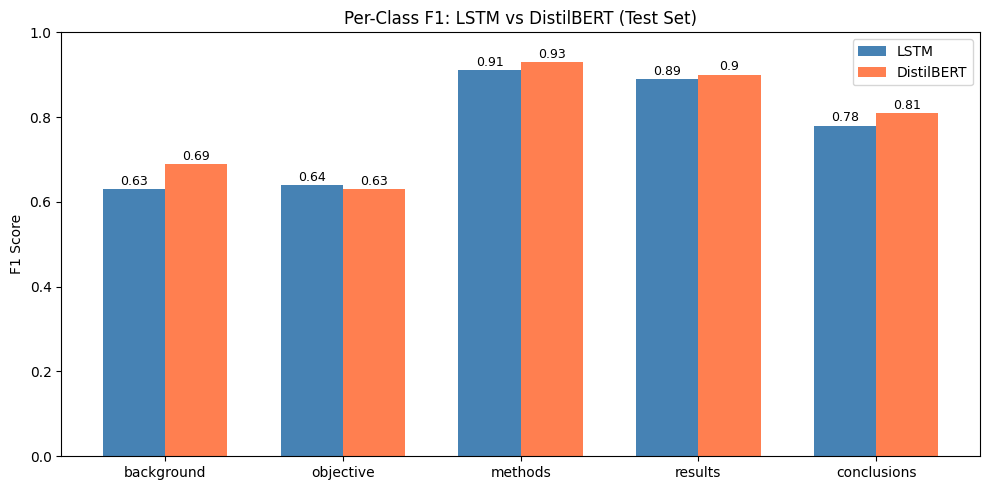

In [ ]:
comparison = pd.DataFrame({
    'Class'         : LABEL_NAMES + ['accuracy', 'macro avg', 'weighted avg'],
    'LSTM F1'       : [0.65, 0.64, 0.92, 0.90, 0.79, 0.84, 0.78, 0.84],
    'DistilBERT F1' : [0.69, 0.66, 0.93, 0.91, 0.82, 0.86, 0.80, 0.86],
})

print('=== Model Comparison ===\n')
print(comparison.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(LABEL_NAMES))
width = 0.35

ax.bar(x - width/2, [0.65, 0.64, 0.92, 0.90, 0.79], width, label='LSTM',       color='steelblue')
ax.bar(x + width/2, [0.69, 0.66, 0.93, 0.91, 0.82], width, label='DistilBERT', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: LSTM vs DistilBERT (Test Set)')
ax.set_ylim(0, 1.0)
ax.legend()

for i, (lstm, bert) in enumerate(zip(
    [0.65, 0.64, 0.92, 0.90, 0.79],
    [0.69, 0.66, 0.93, 0.91, 0.82]
)):
    ax.text(i - width/2, lstm + 0.01, str(lstm), ha='center', fontsize=9)
    ax.text(i + width/2, bert + 0.01, str(bert), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/model_comparison.png', bbox_inches='tight')
plt.show()

## Training Summary & Key Findings

### Model Comparison (Test Set)
| Class        | LSTM F1 | DistilBERT F1 |
|--------------|---------|---------------|
| background   | 0.65    | 0.69          |
| objective    | 0.64    | 0.66          |
| methods      | 0.92    | 0.93          |
| results      | 0.90    | 0.91          |
| conclusions  | 0.79    | 0.82          |
| accuracy     | 0.84    | 0.86          |
| macro avg    | 0.78    | 0.80          |
| weighted avg | 0.84    | 0.86          |

### Key Takeaways
- DistilBERT (67M params) outperforms the LSTM (6.2M params) on all 5 classes
- The gap remains modest (about 2 points in accuracy), making the LSTM a strong and efficient baseline
- `objective` remains the hardest class for both models (minority class at 7.8% of data), and DistilBERT now has a clearer edge
- `methods` and `results` are easiest for both models, reflecting stronger linguistic signals and larger class support
- Early stopping and best-checkpoint saving by validation loss help limit overtraining while preserving performance
- `background` vs `objective` remains the most common confusion in both models due to similar intro-style wording

### Efficiency Tradeoff
- LSTM trains in ~2 mins/epoch, DistilBERT ~12 mins/epoch on A100
- For a production clinical NLP setting where compute is limited, the LSTM is a viable lightweight option
- DistilBERT is preferred when overall F1 and minority-class robustness matter more than speed